In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option('display.float_format', '{:,.3f}'.format)

In [2]:
df = pd.read_csv('data/20_dataset_customer_segmentation_large.csv')
df.head(7)

,customer_id,orders_12m,spend_12m_eur,website_visits_90d,avg_discount_rate,return_rate,days_since_last_order,support_tickets_12m,avg_order_value_eur,mobile_share,newsletter_open_rate,loyalty_years
0,1,4.000,80.540,7.000,0.238,0.056,16.000,0.000,21.010,0.028,0.256,0.240
1,2,22.000,"2,415.740",65.000,0.014,NaN,8.000,3.000,109.750,0.254,0.119,1.980
2,3,8.000,789.730,29.000,0.042,0.015,14.000,2.000,103.000,0.136,0.335,1.960
3,4,3.000,449.670,29.000,0.072,0.064,11.000,0.000,152.330,0.084,0.282,2.760
4,5,8.000,672.520,27.000,0.043,0.072,17.000,2.000,84.740,0.119,0.220,3.320
5,6,15.000,576.640,43.000,0.423,0.143,5.000,1.000,37.850,0.603,0.320,0.970
6,7,1.000,53.380,1.000,0.022,0.011,89.000,1.000,53.380,0.177,0.000,1.260


In [3]:
df.shape

(12000, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            12000 non-null  int64  
 1   orders_12m             12000 non-null  float64
 2   spend_12m_eur          12000 non-null  float64
 3   website_visits_90d     12000 non-null  float64
 4   avg_discount_rate      11880 non-null  float64
 5   return_rate            11880 non-null  float64
 6   days_since_last_order  12000 non-null  float64
 7   support_tickets_12m    12000 non-null  float64
 8   avg_order_value_eur    12000 non-null  float64
 9   mobile_share           12000 non-null  float64
 10  newsletter_open_rate   11820 non-null  float64
 11  loyalty_years          11880 non-null  float64
dtypes: float64(11), int64(1)
memory usage: 1.1 MB


In [5]:
df.isna().sum()

customer_id                0
orders_12m                 0
spend_12m_eur              0
website_visits_90d         0
avg_discount_rate        120
return_rate              120
days_since_last_order      0
support_tickets_12m        0
avg_order_value_eur        0
mobile_share               0
newsletter_open_rate     180
loyalty_years            120
dtype: int64

In [6]:
df.describe()

,customer_id,orders_12m,spend_12m_eur,website_visits_90d,avg_discount_rate,return_rate,days_since_last_order,support_tickets_12m,avg_order_value_eur,mobile_share,newsletter_open_rate,loyalty_years
count,"12,000.000","12,000.000","12,000.000","12,000.000","11,880.000","11,880.000","12,000.000","12,000.000","12,000.000","12,000.000","11,820.000","11,880.000"
mean,"6,000.500",11.928,591.376,26.446,0.154,0.049,26.195,0.985,53.673,0.420,0.206,1.457
std,"3,464.246",10.125,623.285,20.164,0.118,0.034,30.950,0.941,42.733,0.206,0.122,0.918
min,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.006,0.000,0.000
25%,"3,000.750",3.000,128.745,8.000,0.069,0.025,7.000,0.000,29.640,0.260,0.117,0.750
50%,"6,000.500",10.000,443.000,25.000,0.123,0.046,14.000,1.000,44.070,0.406,0.204,1.440
75%,"9,000.250",17.000,705.520,40.000,0.205,0.069,34.000,2.000,65.620,0.568,0.290,2.100
max,"12,000.000",88.759,"9,551.273",103.000,0.673,0.243,215.000,5.000,786.640,1.000,0.632,4.680


In [7]:
features = [
    'orders_12m',
    'spend_12m_eur',
    'website_visits_90d',
    'avg_discount_rate',
    'return_rate',
    'days_since_last_order',
    'support_tickets_12m',
    'avg_order_value_eur',
    'mobile_share',
    'newsletter_open_rate',
    'loyalty_years'
]

for column in features:
    df[column] = df[column].fillna(df[column].median())

df.isna().sum()

customer_id              0
orders_12m               0
spend_12m_eur            0
website_visits_90d       0
avg_discount_rate        0
return_rate              0
days_since_last_order    0
support_tickets_12m      0
avg_order_value_eur      0
mobile_share             0
newsletter_open_rate     0
loyalty_years            0
dtype: int64

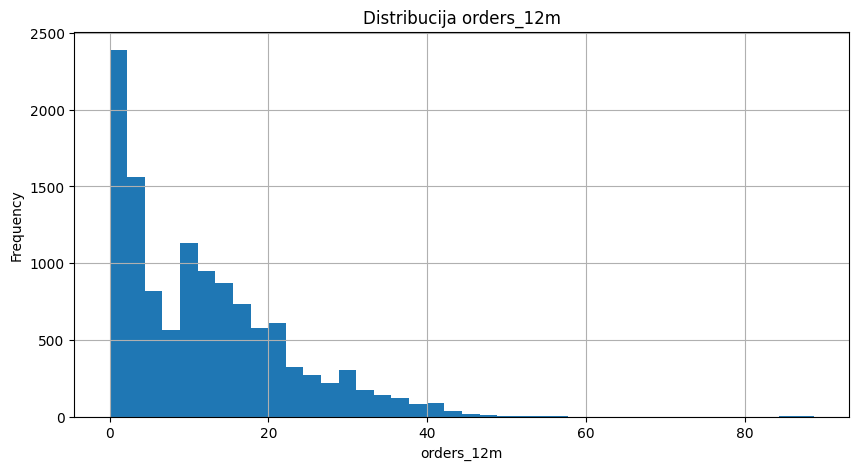

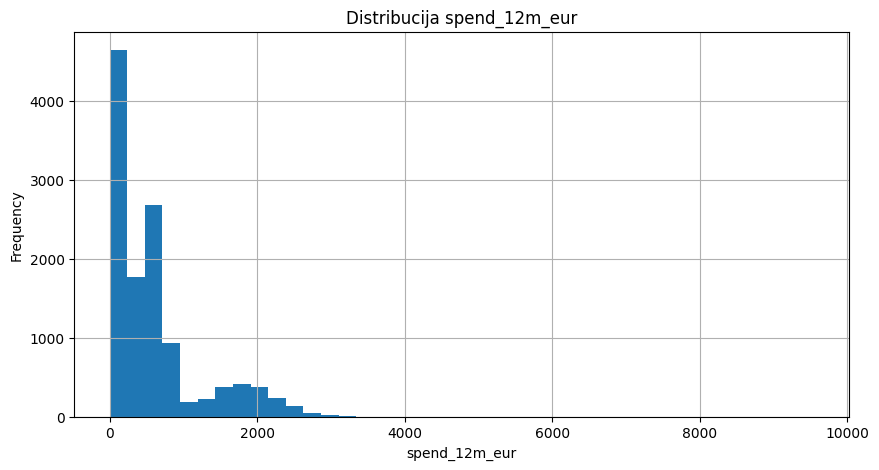

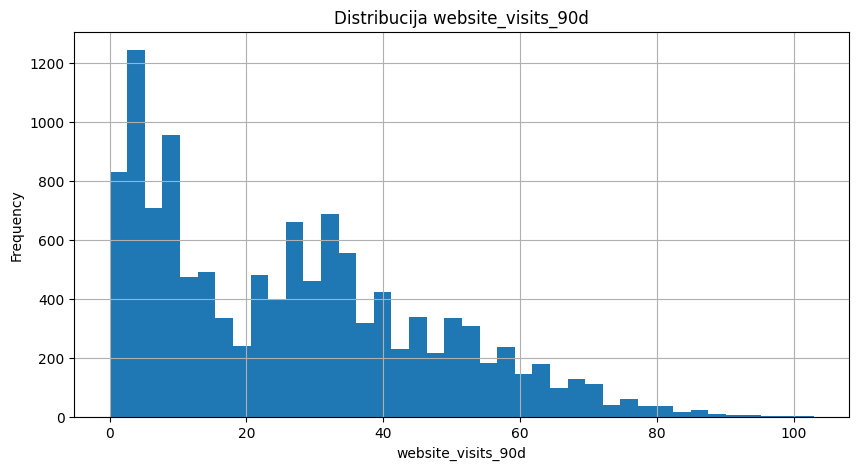

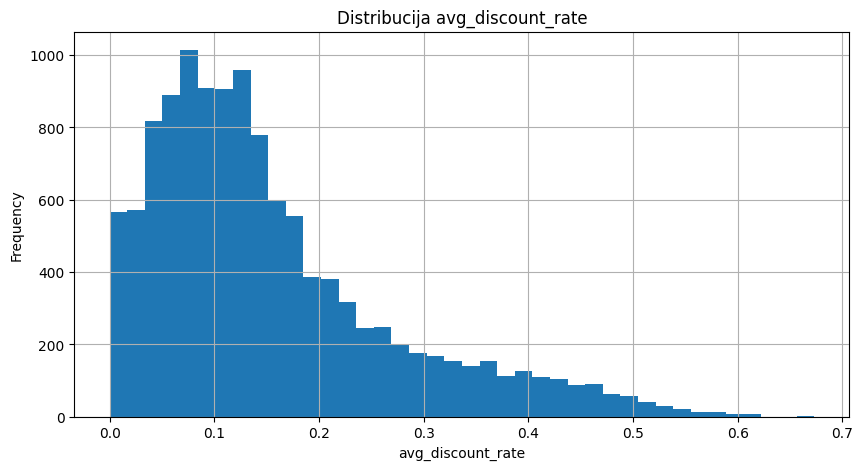

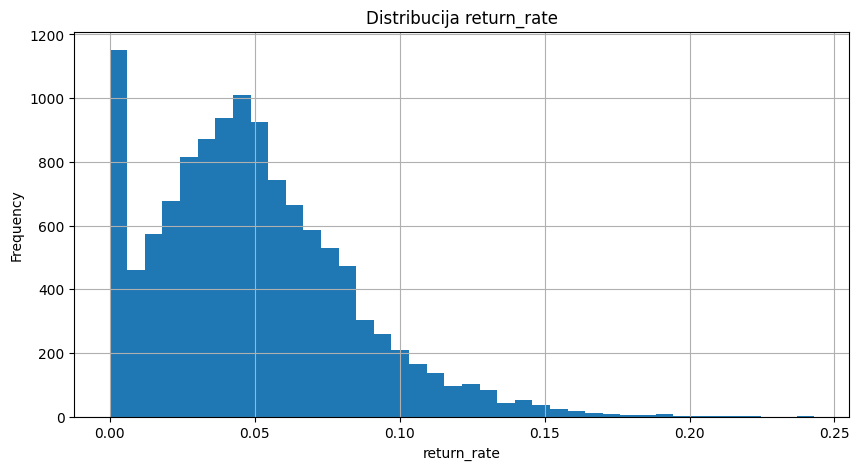

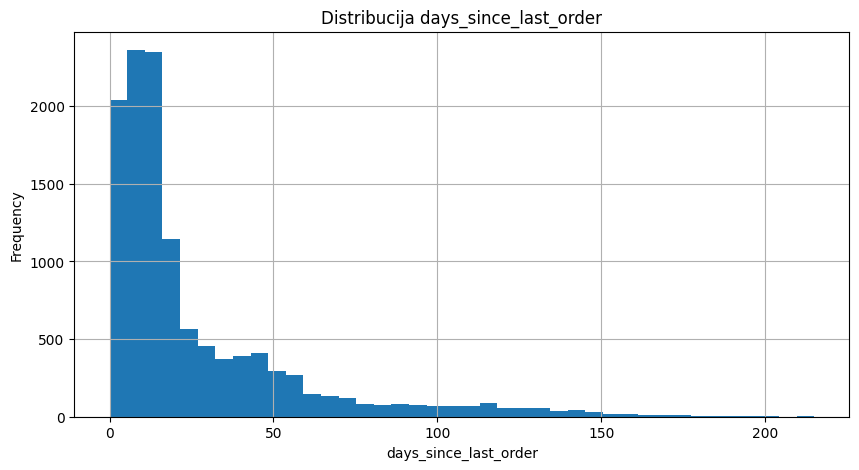

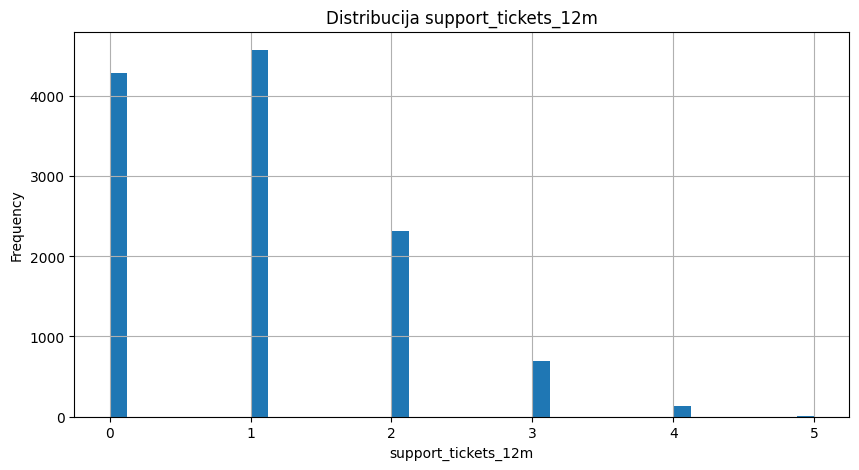

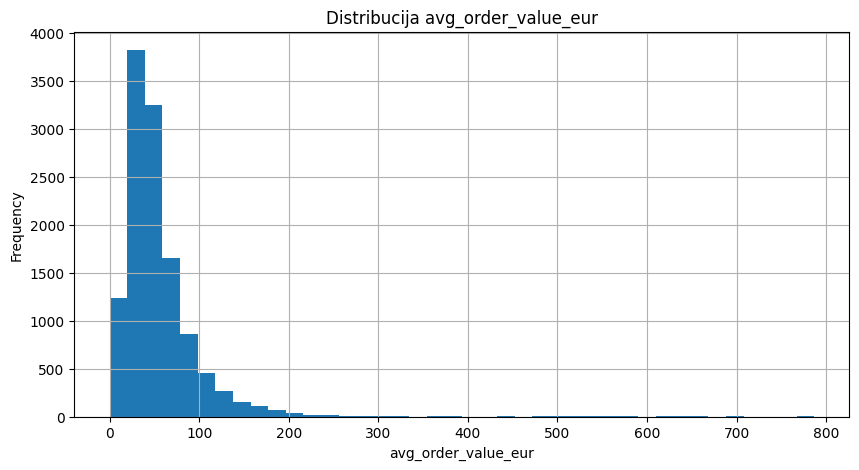

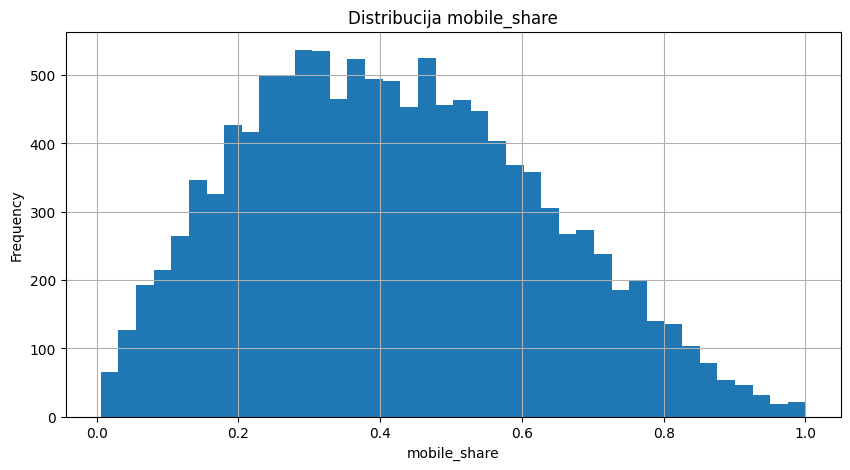

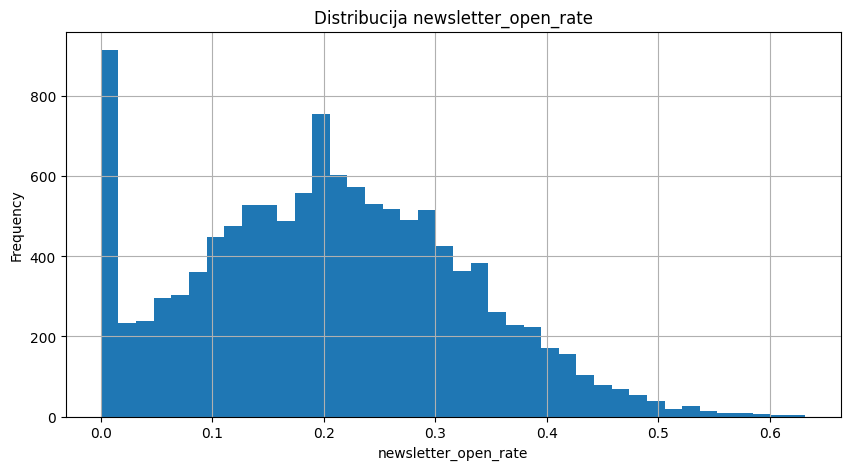

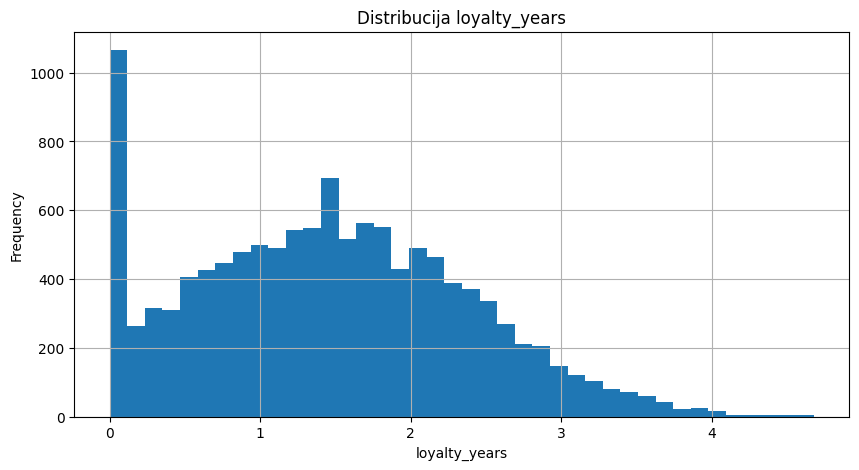

In [9]:
for column in features:
    df[column].plot(
        kind='hist',
        bins=40,
        figsize=(10, 5),
        title=f'Distribucija {column}'
    )
    plt.xlabel(column)
    plt.grid(True)
    plt.show()

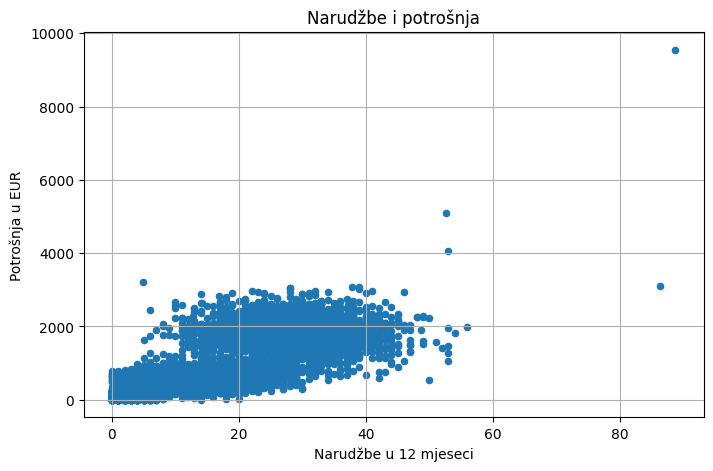

In [10]:
df.plot(kind="scatter", x="orders_12m", y="spend_12m_eur", figsize=(8, 5), title="Narudžbe i potrošnja")
plt.xlabel("Narudžbe u 12 mjeseci")
plt.ylabel("Potrošnja u EUR")
plt.grid(True)
plt.show()

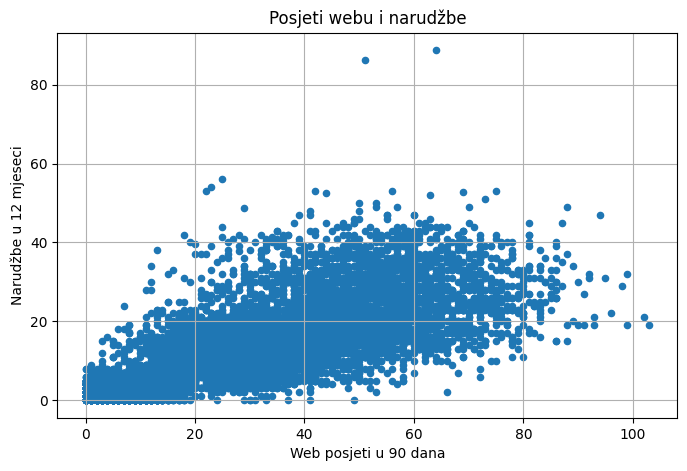

In [11]:
df.plot(kind="scatter", x="website_visits_90d", y="orders_12m", figsize=(8, 5), title="Posjeti webu i narudžbe")
plt.xlabel("Web posjeti u 90 dana")
plt.ylabel("Narudžbe u 12 mjeseci")
plt.grid(True)
plt.show()

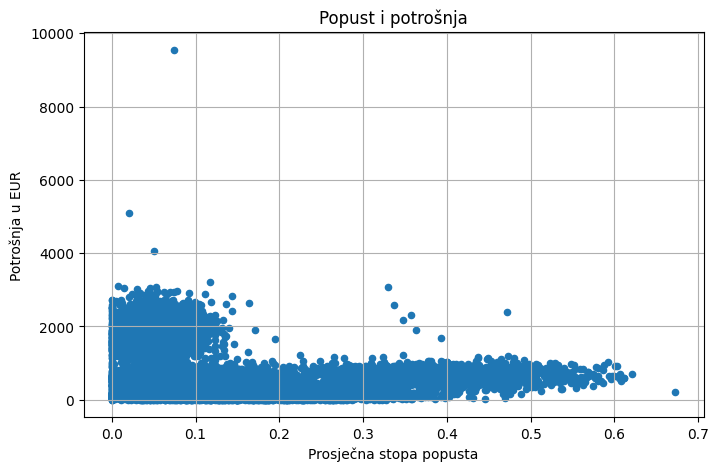

In [12]:
df.plot(kind="scatter", x="avg_discount_rate", y="spend_12m_eur", figsize=(8, 5), title="Popust i potrošnja")
plt.xlabel("Prosječna stopa popusta")
plt.ylabel("Potrošnja u EUR")
plt.grid(True)
plt.show()

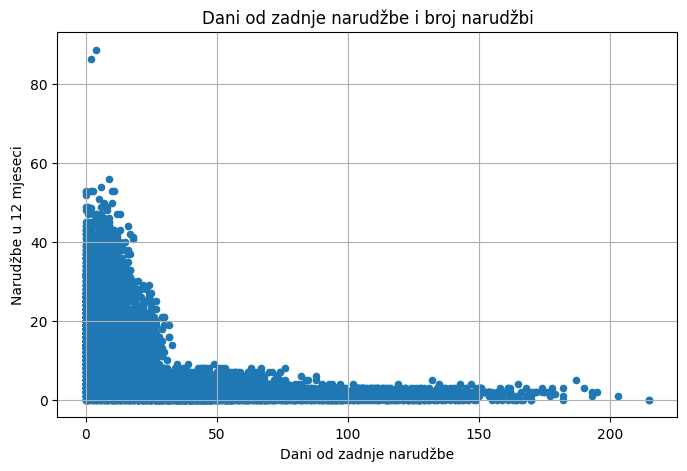

In [13]:
df.plot(kind="scatter", x="days_since_last_order", y="orders_12m", figsize=(8, 5), title="Dani od zadnje narudžbe i broj narudžbi")
plt.xlabel("Dani od zadnje narudžbe")
plt.ylabel("Narudžbe u 12 mjeseci")
plt.grid(True)
plt.show()

In [14]:
X = df[features].copy()
X.head()

,orders_12m,spend_12m_eur,website_visits_90d,avg_discount_rate,return_rate,days_since_last_order,support_tickets_12m,avg_order_value_eur,mobile_share,newsletter_open_rate,loyalty_years
0,4.000,80.540,7.000,0.238,0.056,16.000,0.000,21.010,0.028,0.256,0.240
1,22.000,"2,415.740",65.000,0.014,0.046,8.000,3.000,109.750,0.254,0.119,1.980
2,8.000,789.730,29.000,0.042,0.015,14.000,2.000,103.000,0.136,0.335,1.960
3,3.000,449.670,29.000,0.072,0.064,11.000,0.000,152.330,0.084,0.282,2.760
4,8.000,672.520,27.000,0.043,0.072,17.000,2.000,84.740,0.119,0.220,3.320


In [17]:
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)
X_scaled[:5]

array([[-0.78305775, -0.81962084, -0.96443584,  0.71936643,  0.20290628,
        -0.32942795, -1.04687275, -0.7644005 , -1.90179779,  0.41746239,
        -1.33264865],
       [ 0.99485517,  2.92713457,  1.91210838, -1.18830612, -0.09666008,
        -0.58791897,  2.14022399,  1.31232029, -0.80638196, -0.71669695,
         0.57330241],
       [-0.38796599,  0.31825235,  0.12666714, -0.94984705, -1.02531577,
        -0.39405071,  1.07785841,  1.15435471, -1.37832474,  1.07146668,
         0.55139493],
       [-0.88183069, -0.22736329,  0.12666714, -0.69435519,  0.44255936,
        -0.49098484, -1.04687275,  2.30879055, -1.63036731,  0.63270431,
         1.42769427],
       [-0.38796599,  0.13019257,  0.02747596, -0.94133066,  0.68221244,
        -0.29711657,  1.07785841,  0.72702857, -1.46072327,  0.11943512,
         2.04110381]])

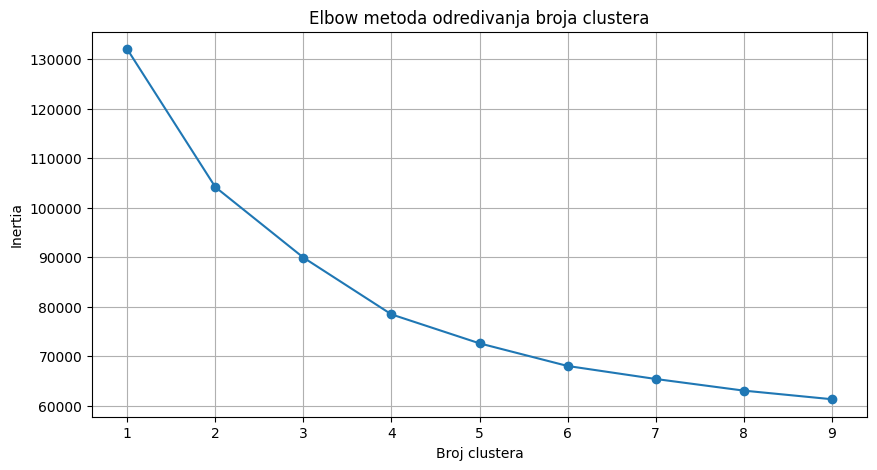

In [18]:
inertias = []
k_values = range(1, 10)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(list(k_values), inertias, marker='o')
plt.title('Elbow metoda odredivanja broja clustera')
plt.xlabel('Broj clustera')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [26]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['clusters'] = kmeans.fit_predict(X_scaled)
df.head()

,customer_id,orders_12m,spend_12m_eur,website_visits_90d,avg_discount_rate,return_rate,days_since_last_order,support_tickets_12m,avg_order_value_eur,mobile_share,newsletter_open_rate,loyalty_years,clusters
0,1,4.000,80.540,7.000,0.238,0.056,16.000,0.000,21.010,0.028,0.256,0.240,0
1,2,22.000,"2,415.740",65.000,0.014,0.046,8.000,3.000,109.750,0.254,0.119,1.980,2
2,3,8.000,789.730,29.000,0.042,0.015,14.000,2.000,103.000,0.136,0.335,1.960,4
3,4,3.000,449.670,29.000,0.072,0.064,11.000,0.000,152.330,0.084,0.282,2.760,4
4,5,8.000,672.520,27.000,0.043,0.072,17.000,2.000,84.740,0.119,0.220,3.320,4


In [27]:
df.clusters.value_counts(normalize=True)

clusters
4   0.325
0   0.283
2   0.160
1   0.131
3   0.101
Name: proportion, dtype: float64

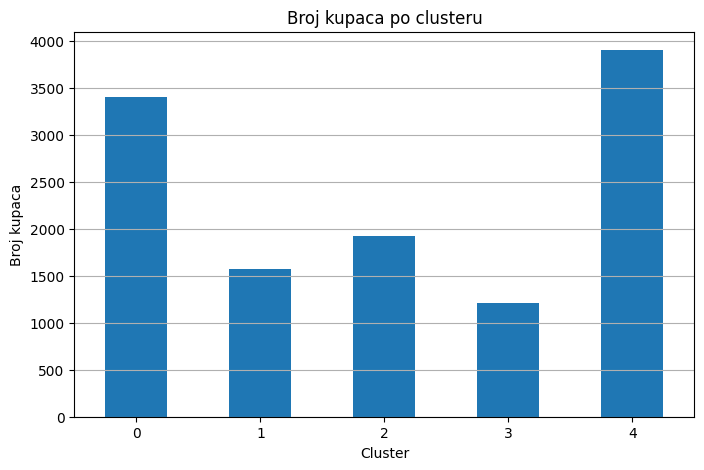

In [29]:
df["clusters"].value_counts().sort_index().plot(kind="bar", figsize=(8, 5), title="Broj kupaca po clusteru")
plt.xlabel("Cluster")
plt.ylabel("Broj kupaca")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [30]:
cluster_profile = df.groupby("clusters")[features].mean()
cluster_profile

,orders_12m,spend_12m_eur,website_visits_90d,avg_discount_rate,return_rate,days_since_last_order,support_tickets_12m,avg_order_value_eur,mobile_share,newsletter_open_rate,loyalty_years
clusters,,,,,,,,,,,
0,3.296,137.103,8.469,0.175,0.041,34.073,0.662,54.999,0.403,0.222,0.884
1,17.928,650.686,44.379,0.380,0.093,10.405,1.288,40.053,0.557,0.218,0.938
2,28.360,"1,828.632",54.908,0.053,0.036,6.142,1.492,74.040,0.394,0.224,1.978
3,1.641,76.877,3.326,0.122,0.031,101.458,0.392,50.440,0.395,0.068,1.005
4,12.143,514.398,28.066,0.103,0.051,12.154,1.081,48.991,0.401,0.220,2.048


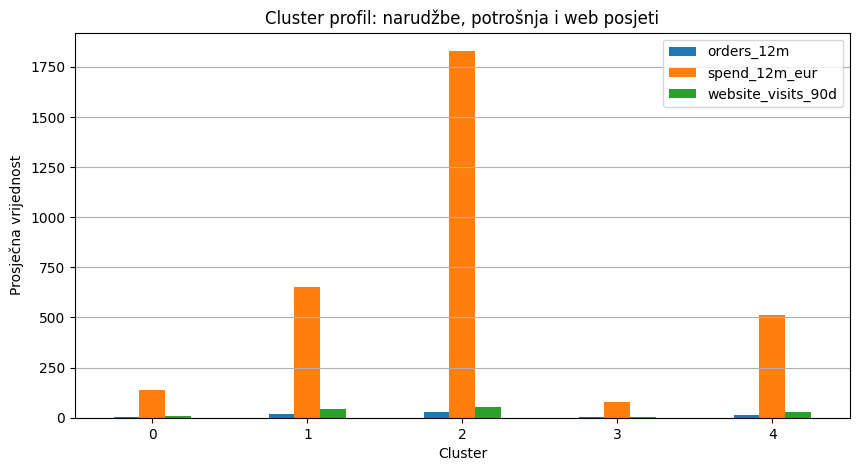

In [31]:
cluster_profile[["orders_12m", "spend_12m_eur", "website_visits_90d"]].plot(
    kind="bar",
    figsize=(10, 5),
    title="Cluster profil: narudžbe, potrošnja i web posjeti"
)
plt.xlabel("Cluster")
plt.ylabel("Prosječna vrijednost")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

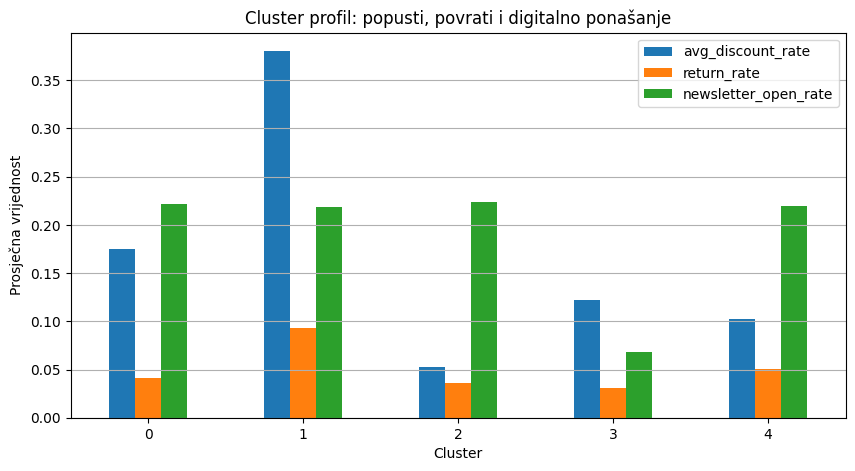

In [33]:
cluster_profile[["avg_discount_rate", "return_rate", "newsletter_open_rate"]].plot(
    kind="bar",
    figsize=(10, 5),
    title="Cluster profil: popusti, povrati i digitalno ponašanje"
)
plt.xlabel("Cluster")
plt.ylabel("Prosječna vrijednost")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

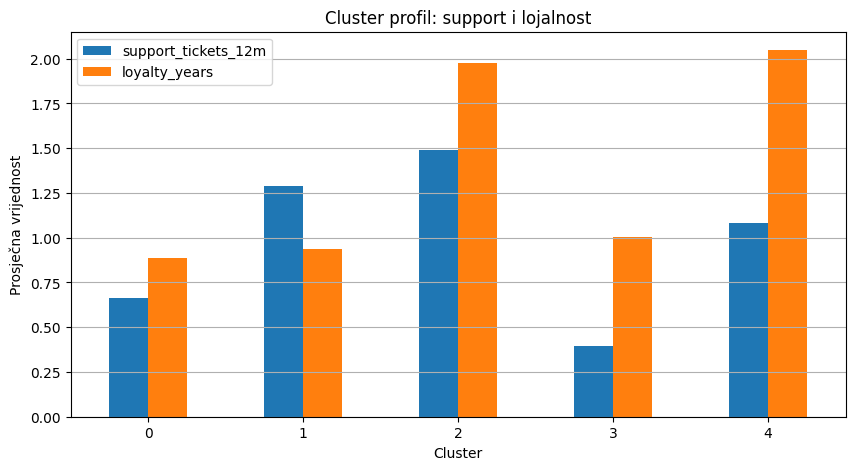

In [36]:
cluster_profile[["support_tickets_12m", "loyalty_years"]].plot(
    kind="bar",
    figsize=(10, 5),
    title="Cluster profil: support i lojalnost"
)
plt.xlabel("Cluster")
plt.ylabel("Prosječna vrijednost")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

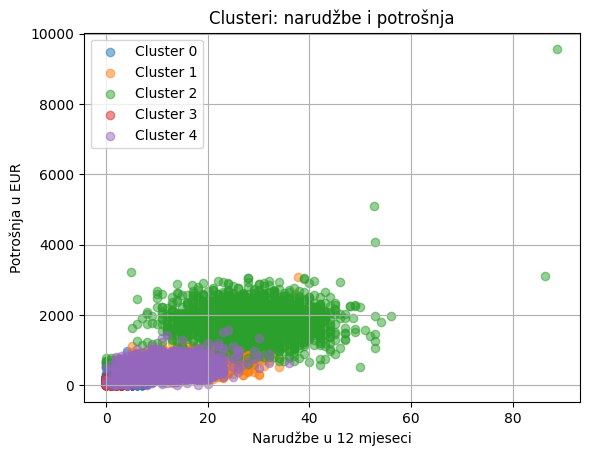

In [38]:
for cluster_id in sorted(df["clusters"].unique()):
    subset = df[df["clusters"] == cluster_id]
    plt.scatter(subset["orders_12m"], subset["spend_12m_eur"], label=f"Cluster {cluster_id}", alpha=0.5)

plt.title("Clusteri: narudžbe i potrošnja")
plt.xlabel("Narudžbe u 12 mjeseci")
plt.ylabel("Potrošnja u EUR")
plt.legend()
plt.grid(True)
plt.show()

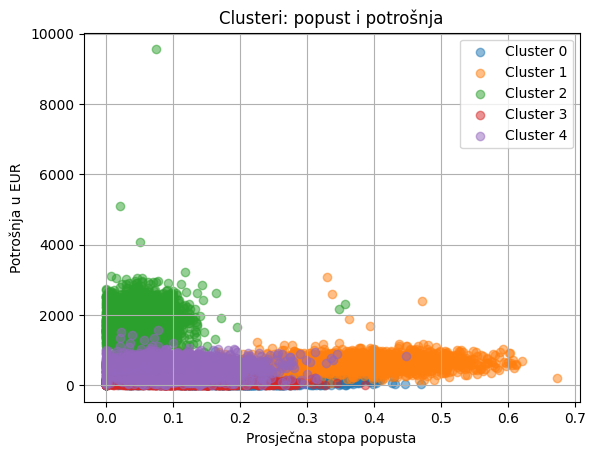

In [40]:
for cluster_id in sorted(df["clusters"].unique()):
    subset = df[df["clusters"] == cluster_id]
    plt.scatter(subset["avg_discount_rate"], subset["spend_12m_eur"], label=f"Cluster {cluster_id}", alpha=0.5)

plt.title("Clusteri: popust i potrošnja")
plt.xlabel("Prosječna stopa popusta")
plt.ylabel("Potrošnja u EUR")
plt.legend()
plt.grid(True)
plt.show()

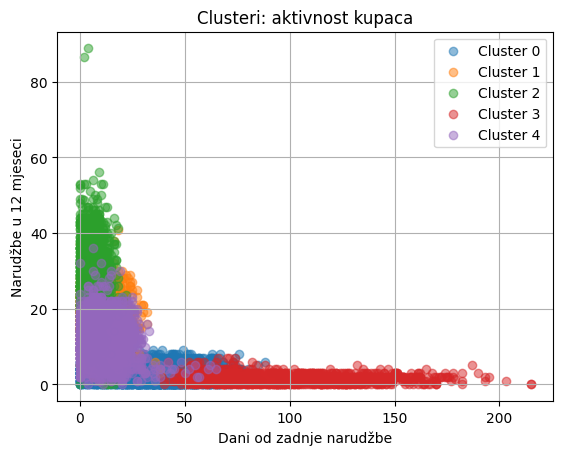

In [41]:
for cluster_id in sorted(df["clusters"].unique()):
    subset = df[df["clusters"] == cluster_id]
    plt.scatter(subset["days_since_last_order"], subset["orders_12m"], label=f"Cluster {cluster_id}", alpha=0.5)

plt.title("Clusteri: aktivnost kupaca")
plt.xlabel("Dani od zadnje narudžbe")
plt.ylabel("Narudžbe u 12 mjeseci")
plt.legend()
plt.grid(True)
plt.show()

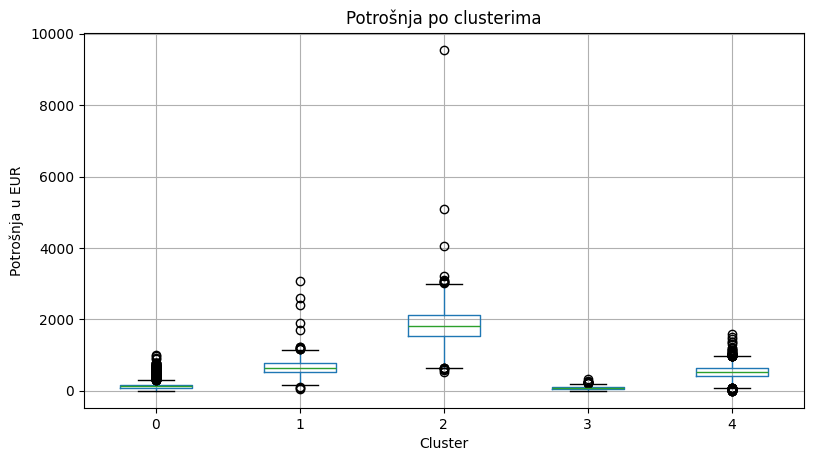

In [43]:
df.boxplot(column="spend_12m_eur", by="clusters", figsize=(9, 5))
plt.title("Potrošnja po clusterima")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Potrošnja u EUR")
plt.grid(True)
plt.show()

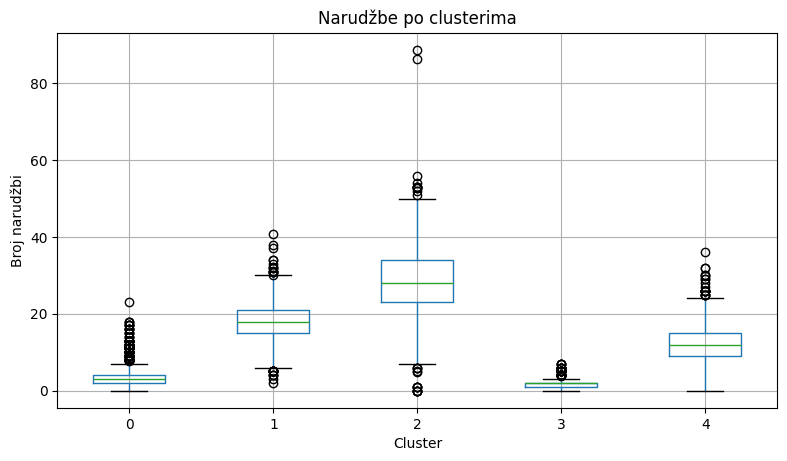

In [44]:
df.boxplot(column="orders_12m", by="clusters", figsize=(9, 5))
plt.title("Narudžbe po clusterima")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Broj narudžbi")
plt.grid(True)
plt.show()

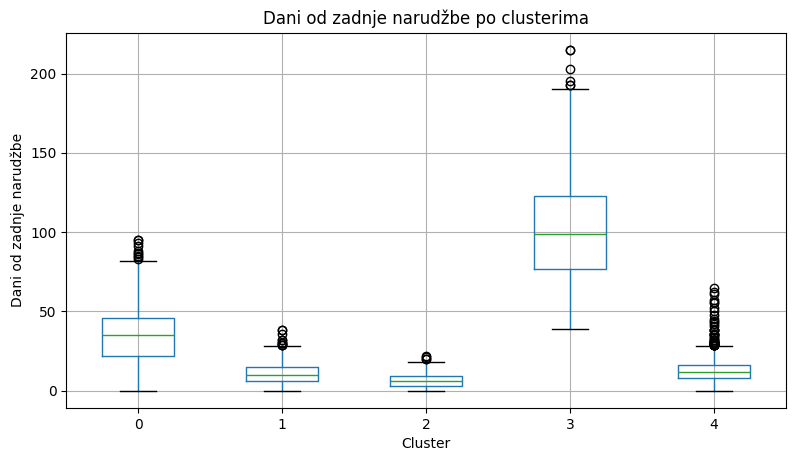

In [45]:
df.boxplot(column="days_since_last_order", by="clusters", figsize=(9, 5))
plt.title("Dani od zadnje narudžbe po clusterima")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Dani od zadnje narudžbe")
plt.grid(True)
plt.show()

In [46]:
profile_normalized = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()
profile_normalized

,orders_12m,spend_12m_eur,website_visits_90d,avg_discount_rate,return_rate,days_since_last_order,support_tickets_12m,avg_order_value_eur,mobile_share,newsletter_open_rate,loyalty_years
clusters,,,,,,,,,,,
0,-0.853,-0.714,-0.870,0.067,-0.373,0.031,-0.712,0.103,-0.376,0.463,-0.826
1,0.478,0.013,0.743,1.680,1.709,-0.563,0.676,-1.084,1.786,0.405,-0.735
2,1.427,1.679,1.216,-0.894,-0.577,-0.670,1.129,1.615,-0.504,0.487,1.032
3,-1.003,-0.799,-1.101,-0.351,-0.780,1.721,-1.309,-0.259,-0.498,-1.788,-0.622
4,-0.048,-0.180,0.011,-0.502,0.021,-0.519,0.217,-0.374,-0.408,0.433,1.151


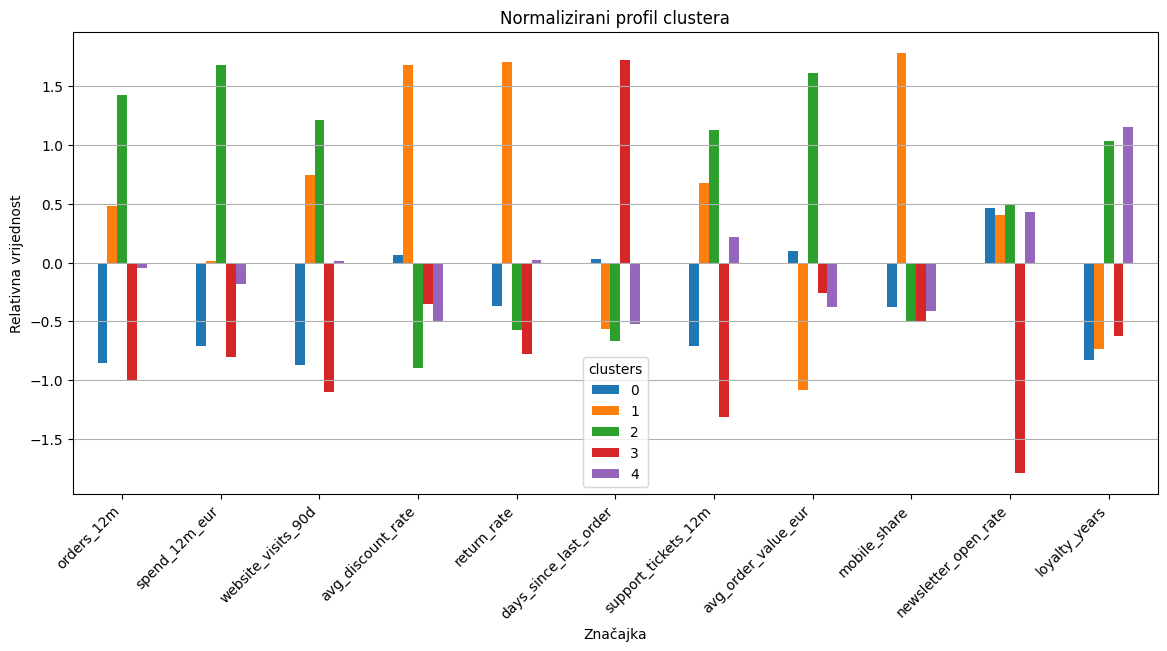

In [47]:
profile_normalized.T.plot(kind="bar", figsize=(14, 6), title="Normalizirani profil clustera")
plt.xlabel("Značajka")
plt.ylabel("Relativna vrijednost")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()